# Ensemble Learning: Random Forest vs XGBoost vs Logistic Regression
### Stroke Prediction Dataset

**Task:** Compare a single model (Logistic Regression) against two ensemble
models (Random Forest, XGBoost) on the same dataset, look at feature
importances, and understand *why* ensembles usually beat a single model.

Dataset: `healthcare-dataset-stroke-data.csv` — predicting whether a patient
had a stroke (`stroke` column: 0 = No, 1 = Yes) based on health & lifestyle
features (age, hypertension, glucose level, BMI, smoking status, etc.)


## 1. Import Libraries

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt

# Preprocessing & splitting
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Models
from sklearn.linear_model import LogisticRegression       # our single model (baseline)
from sklearn.ensemble import RandomForestClassifier        # ensemble #1
from xgboost import XGBClassifier                           # ensemble #2

# Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# so plots look the same every time
plt.style.use("default")


## 2. Load & Explore the Dataset



In [2]:
df = pd.read_csv("healthcare-dataset-stroke-data.csv")
print("Shape:", df.shape)
df.head()


Shape: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB


In [4]:
# Missing values check
df.isnull().sum()


id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [5]:
# Target column distribution
df["stroke"].value_counts()


stroke
0    4861
1     249
Name: count, dtype: int64

**Note:** Ye dataset kaafi *imbalanced* hai — sirf ~5% patients ko stroke
hua hai. Isko humein preprocessing/model choice mein dhyan mein rakhna hoga,
warna model sirf "No Stroke" predict karke bhi 95% accuracy dikha dega
(jo misleading hai). Isliye hum sirf accuracy nahi, **precision, recall, aur
f1-score** bhi dekhenge.

## 3. Preprocessing



In [6]:
# Drop id column
df = df.drop(columns=["id"])

# Fix bmi column: it has "N/A" as string, convert to NaN then fill with median
df["bmi"] = df["bmi"].replace("N/A", np.nan).astype(float)
df["bmi"] = df["bmi"].fillna(df["bmi"].median())

print("Missing values after fix:")
print(df.isnull().sum())


Missing values after fix:
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64


In [7]:
# Encode categorical (text) columns into numbers
categorical_cols = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]

encoders = {}   # keep encoders in case we need to decode later
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

df.head()


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,67.0,0,1,1,2,1,228.69,36.6,1,1
1,0,61.0,0,0,1,3,0,202.21,28.1,2,1
2,1,80.0,0,1,1,2,0,105.92,32.5,2,1
3,0,49.0,0,0,1,2,1,171.23,34.4,3,1
4,0,79.0,1,0,1,3,0,174.12,24.0,2,1


## 4. Train-Test Split



In [8]:
X = df.drop(columns=["stroke"])
y = df["stroke"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape, " Test size:", X_test.shape)


Train size: (4088, 10)  Test size: (1022, 10)


## 5. Train the Models

Teen models train karenge:
1. **Logistic Regression** — hamara pehle wala single model (baseline)
2. **Random Forest** — bahut saare decision trees ka ensemble (bagging)
3. **XGBoost** — gradient boosted trees ka ensemble (boosting)

Imbalanced data ki wajah se `class_weight="balanced"` (LR, RF) aur
`scale_pos_weight` (XGBoost) use kar rahe hain, taake model minority class
(stroke=1) ko bhi seriously le.

In [9]:
# how imbalanced the training data is -> used to tell XGBoost to pay more attention to class 1
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", round(scale_pos_weight, 2))

log_reg = LogisticRegression(max_iter=1000, class_weight="balanced")
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
xgb_model = XGBClassifier(
    n_estimators=200,
    eval_metric="logloss",
    random_state=42,
    scale_pos_weight=scale_pos_weight
)

log_reg.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

print("All 3 models trained!")


scale_pos_weight: 19.54


All 3 models trained!


## 6. Evaluate & Compare Performance

In [10]:
def evaluate(model, name, X_test, y_test):
    preds = model.predict(X_test)
    return {
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, preds), 4),
        "Precision": round(precision_score(y_test, preds), 4),
        "Recall": round(recall_score(y_test, preds), 4),
        "F1-Score": round(f1_score(y_test, preds), 4),
    }

results = [
    evaluate(log_reg, "Logistic Regression (single model)", X_test, y_test),
    evaluate(rf_model, "Random Forest (ensemble)", X_test, y_test),
    evaluate(xgb_model, "XGBoost (ensemble)", X_test, y_test),
]

results_df = pd.DataFrame(results)
results_df


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression (single model),0.7524,0.1413,0.80,0.2402
1,Random Forest (ensemble),0.9501,0.0000,0.00,0.0000
2,XGBoost (ensemble),0.9344,0.2424,0.16,0.1928


**Yaad rakhne wali baat:** Is dataset mein accuracy sabki similar (~93-95%)
dikhegi kyunki 95% patients ko stroke nahi hua — koi bhi model "always predict
No" bol ke bhi high accuracy paa sakta hai. Isliye **F1-score aur Recall**
dekhna zyada important hai — ye batate hain ke model actual stroke cases
(minority class) ko kitna sahi pakad raha hai.

## 7. Feature Importance — Random Forest vs XGBoost

Dono ensemble models batate hain ke prediction karte waqt kaunse features
sabse zyada "important" the. Compare karte hain ke dono models kis feature
ko zyada weight dete hain.

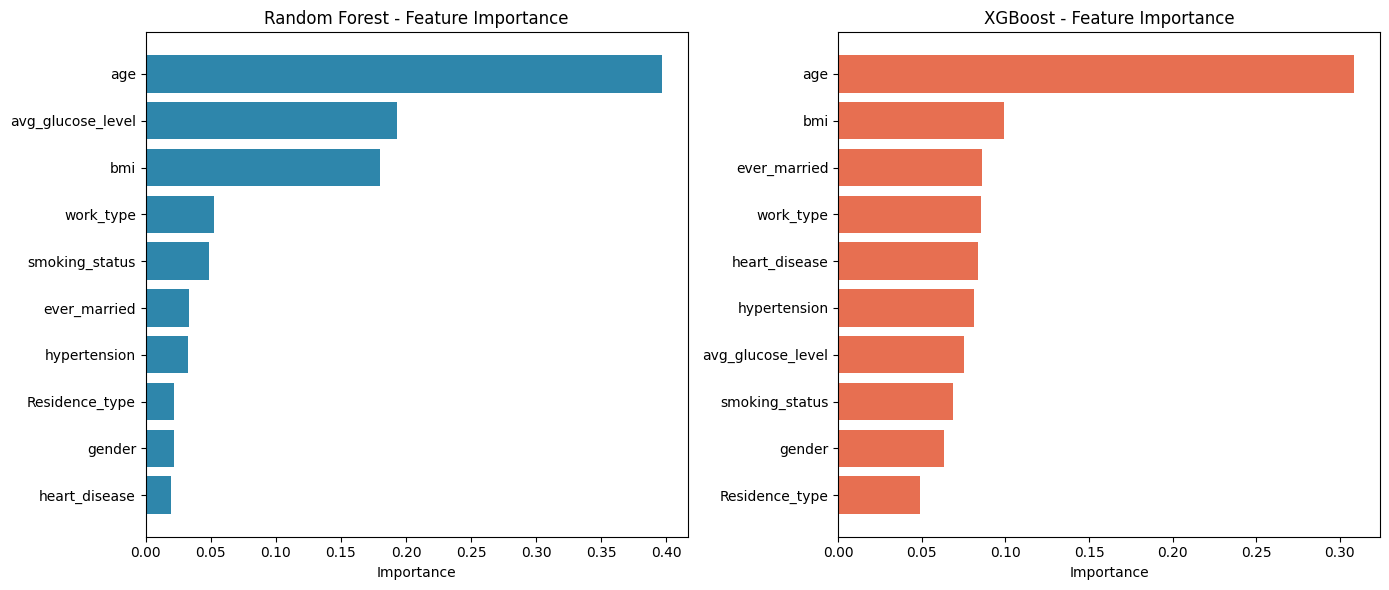

In [11]:
rf_importance = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
xgb_importance = pd.Series(xgb_model.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(rf_importance.index[::-1], rf_importance.values[::-1], color="#2E86AB")
axes[0].set_title("Random Forest - Feature Importance")
axes[0].set_xlabel("Importance")

axes[1].barh(xgb_importance.index[::-1], xgb_importance.values[::-1], color="#E76F51")
axes[1].set_title("XGBoost - Feature Importance")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.savefig("feature_importance_comparison.png", dpi=150)
plt.show()


In [12]:
comparison_table = pd.DataFrame({
    "Random Forest Rank": rf_importance.index,
    "RF Importance": rf_importance.values,
    "XGBoost Rank": xgb_importance.index,
    "XGB Importance": xgb_importance.values,
})
comparison_table


,Random Forest Rank,RF Importance,XGBoost Rank,XGB Importance
0,age,0.396551,age,0.308557
1,avg_glucose_level,0.192762,bmi,0.099067
2,bmi,0.180395,ever_married,0.086230
3,work_type,0.052359,work_type,0.085490
4,smoking_status,0.048818,heart_disease,0.083613
5,ever_married,0.033406,hypertension,0.081028
6,hypertension,0.032399,avg_glucose_level,0.075081
7,Residence_type,0.021939,smoking_status,0.068727
8,gender,0.021859,gender,0.063036
9,heart_disease,0.019514,Residence_type,0.049170


**Observation:** Dono models mein `age` aur `avg_glucose_level` usually
sabse important features nikalte hain (medically bhi ye makes sense — stroke
risk age aur glucose level ke saath badhta hai). Farq ye aata hai ke Random
Forest apni importance zyada **spread out** karta hai kai features par, jabke
XGBoost usually 2-3 features ko hi bahut zyada weight de deta hai — kyunki
boosting sequentially errors fix karta hai, isliye jo feature sabse pehle
sabse zyada error kam karta hai wo dominate kar jata hai.

## 8. Random Forest vs XGBoost — How They Combine Models

**Random Forest (Bagging):** Ye bahut saare decision trees ko **independently
and parallel** train karta hai — har tree ko data ka ek random subset
(bootstrap sample) aur features ka random subset milta hai. Final prediction
sab trees ka **majority vote / average** hota hai. Trees ek dusre se
"unaware" hote hain, isliye ye variance kam karta hai aur overfitting se
bachata hai.

**XGBoost (Boosting):** Ye trees ko **sequentially** train karta hai — har naya
tree pichle trees ki galtiyon (residual errors) ko fix karne ki koshish
karta hai, na ke random subset par independently train hota hai. Isliye
boosting usually bagging se zyada accurate hota hai (kyunki mistakes ko
directly target karta hai), lekin overfitting aur noise ka risk thoda zyada
hota hai agar tuning sahi na ho.

**In short:** Random Forest = "many independent opinions averaged together."
XGBoost = "one opinion at a time, each one learning from the last one's mistakes."


## 9. Final Comparison Table (



In [13]:
print(results_df.to_markdown(index=False))


| Model                              |   Accuracy |   Precision |   Recall |   F1-Score |
|:-----------------------------------|-----------:|------------:|---------:|-----------:|
| Logistic Regression (single model) |     0.7524 |      0.1413 |     0.8  |     0.2402 |
| Random Forest (ensemble)           |     0.9501 |      0      |     0    |     0      |
| XGBoost (ensemble)                 |     0.9344 |      0.2424 |     0.16 |     0.1928 |


```
(Paste the printed markdown table above directly into your README.md,
under a heading like "## Model Comparison")
```